<img src="./logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº2
#### Serena Saggion


# Introducción
En este trabajo se analiza el comportamiento de un convertidor analógico-digital (ADC) de *B* bits, considerando el proceso de muestreo y cuantización de una señal senoidal con ruido aditivo gaussiano. El objetivo es estudiar cómo afectan la resolución del ADC y el nivel de ruido a la señal digitalizada, tanto en el dominio del tiempo como en el de la frecuencia.

# Teoría
## Distribuciones continuas
### Gaussiana o normal
La distribución gaussiana o normal es una distribución de probabilidad continua caracterizada por su forma de campana simétrica respecto de su media. Está definida por dos parámetros: la media 𝜇, que indica el valor central, y la varianza 𝜎^2, que mide la dispersión de los datos.
En esta distribución, los valores cercanos a la media son los más probables, mientras que la probabilidad disminuye a medida que se alejan de ella.
### Uniforme
Es una distribución de probabilidad en la cual todos los valores dentro de un intervalo dado tienen la misma probabilidad de ocurrencia, no existe un valor más probable que otro dentro del rango considerado.

## ADC - Conversor analógico-digital
Un convertidor analógico-digital (ADC) es un dispositivo fundamental en electrónica que permite transformar señales analógicas, continuas en el tiempo y la amplitud, en señales digitales que pueden ser procesadas por sistemas electrónicos. Este proceso es esencial, ya que la mayoría de las señales del mundo real son analógicas, mientras que los sistemas de procesamiento son digitales.

La conversión se realiza en tres etapas principales. En primer lugar, el **muestreo** consiste en tomar valores discretos de la señal analógica a una frecuencia determinada, la cual debe cumplir con el criterio de Nyquist para evitar pérdida de información. Luego, en la etapa de **cuantización**, las amplitudes continuas se aproximan a un conjunto finito de niveles, lo que introduce un error denominado ruido de cuantización. Finalmente, en la **codificación**, cada nivel cuantizado se representa mediante un código binario.

El desempeño de un ADC depende de parámetros como la resolución (cantidad de bits), la frecuencia de muestreo y la precisión.
<div align="center">
    <img src="./ADC.png" align="center" width="70%" /> 
</div>

## Cuantización
La cuantización es el proceso mediante el cual una señal analógica, previamente muestreada en el tiempo, es convertida en una señal discreta en amplitud. Esto implica que los valores continuos de la señal se aproximan al nivel más cercano dentro de un conjunto finito de niveles posibles.

La cantidad de niveles disponibles depende de la resolución del ADC. Para un convertidor de **B bits**, existen \begin{equation}2^B\end{equation}niveles de cuantización. El intervalo entre niveles consecutivos se denomina paso de cuantización **q**, y está dado por el rango total de la señal dividido por la cantidad de niveles.

Este proceso introduce un error, conocido como *error o ruido de cuantización*, definido como la diferencia entre la señal original y la señal cuantizada. Bajo ciertas condiciones, este error puede modelarse como una variable aleatoria uniforme en el intervalo [−q/2,q/2], con potencia:
\begin{equation}Pq = q^2/12\end{equation}

A medida que aumenta la cantidad de bits del ADC, el paso de cuantización disminuye, lo que reduce el error de cuantización y mejora la precisión de la señal digitalizada.

## Decibeles (dB)
Es una unidad logarítmica utilizada para expresar la relación entre dos niveles de potencia o intensidad. Se emplea ampliamente en el análisis de señales, ya que permite representar grandes variaciones de valores de manera más compacta.

La diferencia de potencia entre dos señales se expresa como: \begin{equation}ΔdB=10log_{10}(P2/P1)\end{equation}
En esta escala, un valor de 0 dB indica el nivel de referencia, valores negativos representan potencias menores y valores positivos, potencias mayores.

# Procedimiento
## Ejercicio A
Simulación de un ADC a una frecuencia de muestreo *fs=1000 Hz, 4 bits y un rango analógico de ±VF=2 Volts*. Se tiene en cuenta que la potencia del ruido será \begin{equation}Pn = k*Pq\end{equation}, siendo el factor *k* una escala para la potencia del ruido de cuantización *Pq*.

In [74]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

#%%

def mi_sen(vmax, dc, ff, ph, nn, fs):    
    #vmax, dc,ff,ph tienen valor por defecto
    Ts=1/fs 
    tt=np.arange(nn)*Ts
    xx=dc+vmax*np.sin(2*np.pi*ff*tt + ph)
    return tt,xx


fs=1000 
Ts=1/fs 
N=1000
tt=np.arange(N)*Ts

tt,ss= mi_sen(vmax=np.sqrt(2), dc=0,ff=fs/N, ph=0, nn=N, fs=fs)

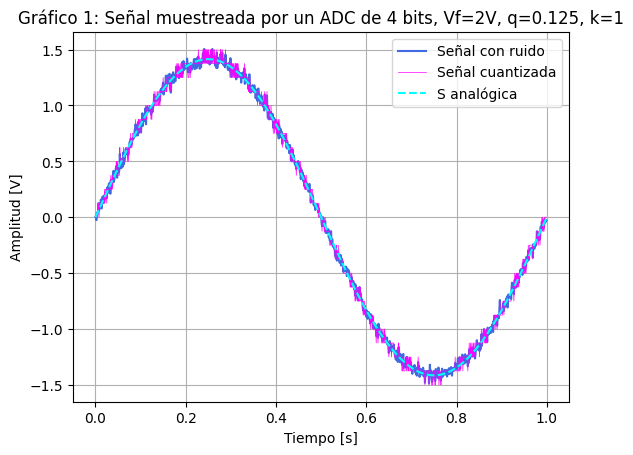

In [75]:
#Ejercico A

#Ruido
#np.random.normal(mu,sigma,size)
B=4
k=1

Vfs = 2
qq = Vfs / 2**B

#Potencia del ruido
Pq=(qq**2)/12
Pn=k*Pq #k es una escala
nn=np.random.normal(0,np.sqrt(Pn),N)  # Ruido gaussiano de media 0 y varianza Pn

sr=ss + nn  #señal+ruido
srq = np.round(sr / qq)  #Cuantización
# Volver a voltios

srq_v = srq * qq

# Gráfico comparación
plt.figure()
plt.plot(tt,sr, label="Señal con ruido", color="royalblue")
plt.plot(tt,srq_v, label="Señal cuantizada", color="fuchsia", linewidth="0.5")
plt.plot(tt,ss, label="S analógica", linestyle="--", color="aqua")
plt.title(f"Gráfico 1: Señal muestreada por un ADC de {B} bits, Vf=2V, q={qq}, k={k}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.grid(True)
plt.show()

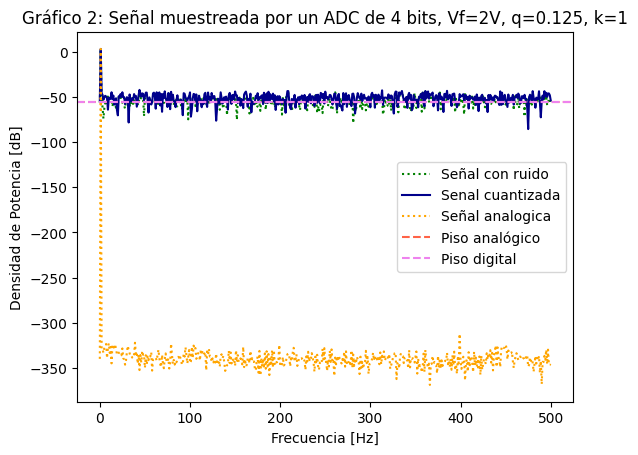

In [76]:
#FFT
SR=np.fft.fft(sr)*2/N  #escalado por 1/N, y se multiplica por 2 para que se tenga en cuenta la otra mitad periodica
SRmod=np.abs(SR)
SS=np.fft.fft(ss)*2/N
SRQ=np.fft.fft(srq_v)*2/N

df=fs/N
ff=np.arange(N)*df
PotSR=(SRmod**2)
PotSR_dB=(10*np.log10(PotSR))
Pot_SRQ=(np.abs(SRQ))**2
Pot_SS=(np.abs(SS))**2
Pot_SRQ_db=(10*np.log10(Pot_SRQ))
Pot_SS_db=(10*np.log10(Pot_SS))
Pd_dB = 10 * np.log10(2 * Pq / N)
Pa_dB  = 10 * np.log10(2 * Pn / N)


bBool=ff<=fs/2
plt.figure()
plt.title(f"Gráfico 2: Señal muestreada por un ADC de {B} bits, Vf=2V, q={qq}, k={k}")
plt.plot(ff[bBool],PotSR_dB[bBool], label="Señal con ruido", color="green", linestyle=":")
plt.plot(ff[bBool],Pot_SRQ_db[bBool], label="Senal cuantizada", color="darkblue")
plt.plot(ff[bBool],Pot_SS_db[bBool], label="Señal analogica", color="orange", linestyle=":")
plt.axhline(Pa_dB, color="tomato", linestyle="--", label="Piso analógico")
plt.axhline(Pd_dB, color="violet", linestyle="--", label="Piso digital")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
plt.legend()
plt.show()

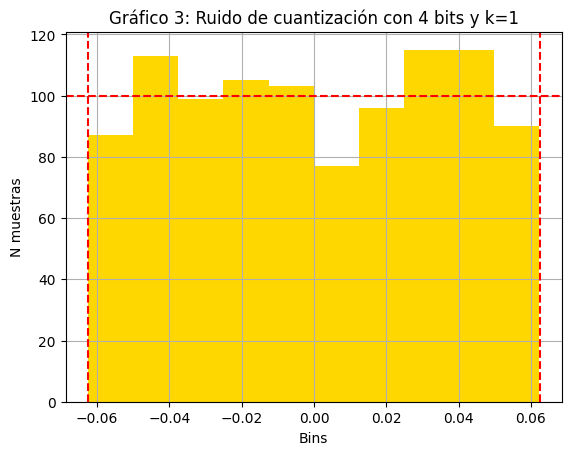

In [77]:
#%%
# Ruido de cuantización
rq = srq_v - sr

bins=10
plt.figure()
plt.hist(rq, bins, color="gold")
plt.axvline(-qq/2, color='red', linestyle='--')
plt.axvline(qq/2, color='red', linestyle='--')
plt.axhline(N/bins, color="red", linestyle="--")
plt.title(f"Gráfico 3: Ruido de cuantización con {B} bits y k={k}")
plt.ylabel("N muestras")
plt.xlabel("Bins")
plt.grid(True)
plt.show()
#%%

## Ejercicio B
Simulación de un ADC manteniendo los valores de frecuencia y rango analógico, variando la cantidad de *bits* y la constante *k* de la potencia del ruido.

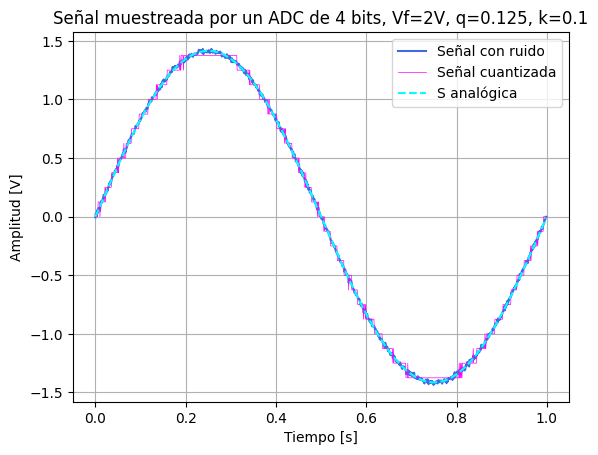

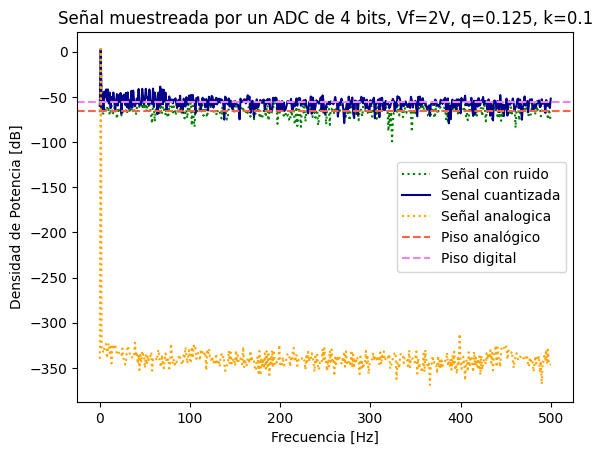

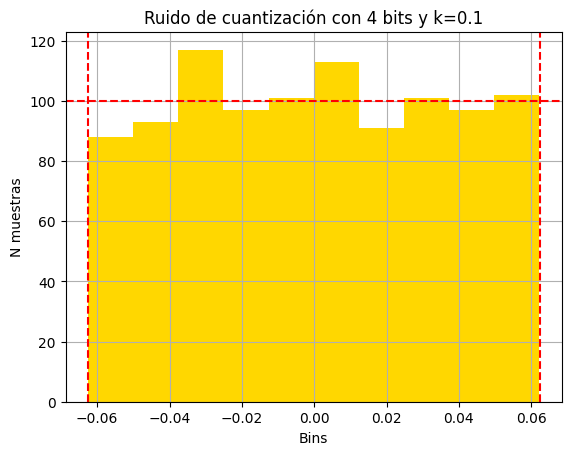

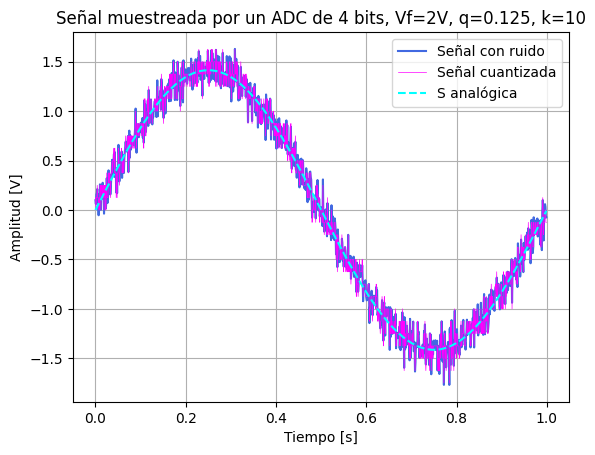

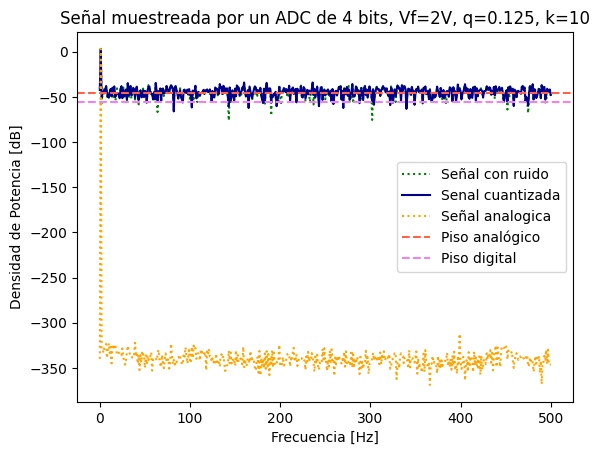

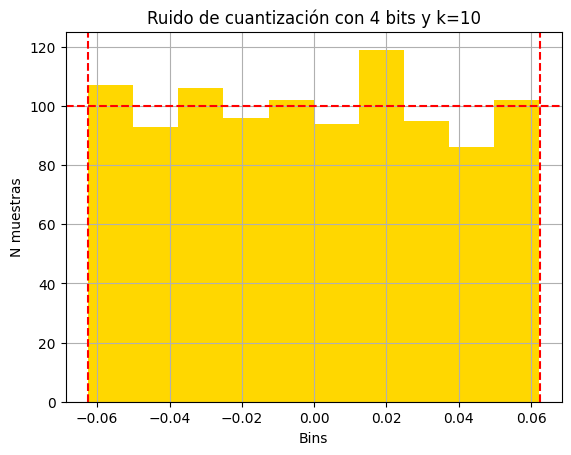

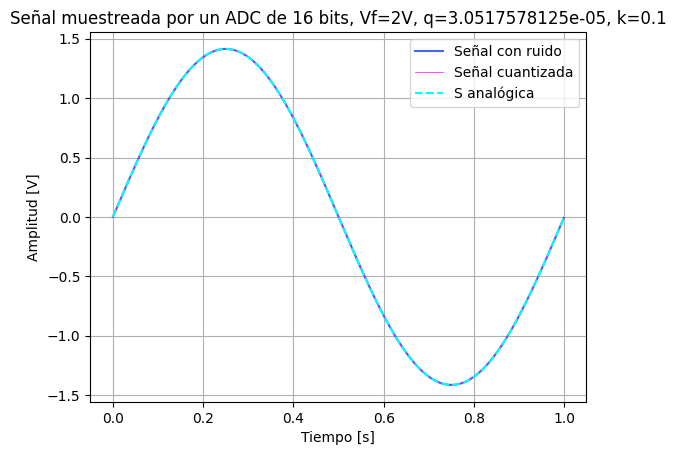

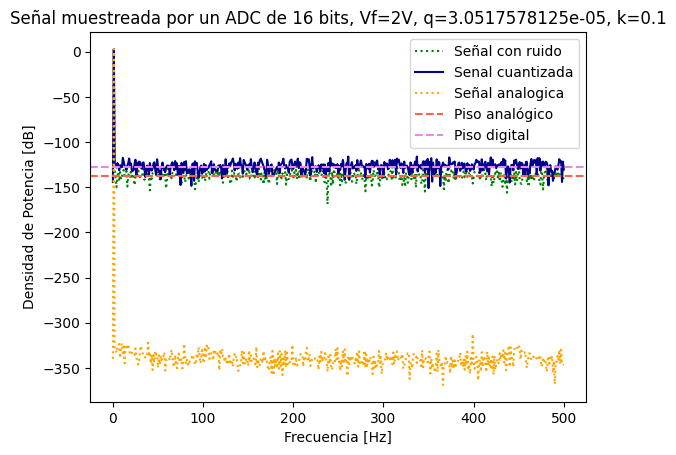

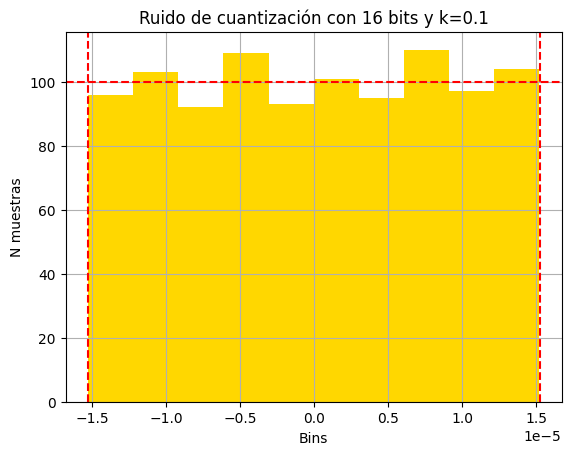

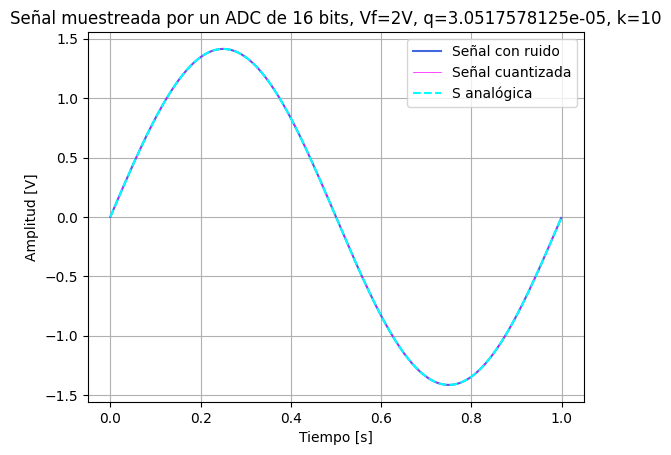

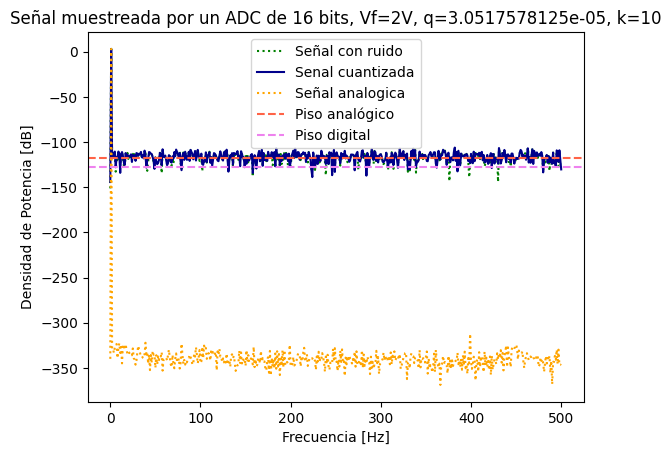

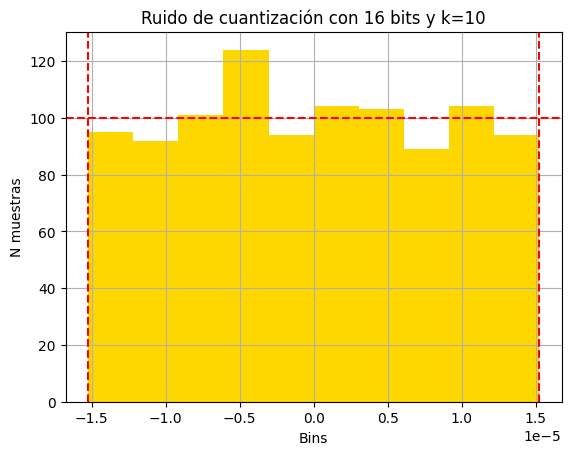

In [78]:
#Ejercicio B

#Ruido
#np.random.normal(mu,sigma,size)
Bits=[4,16]
Ks= [1/10, 10]

for B in Bits:
    for k in Ks:
        Vfs = 2
        qq = Vfs / 2**B

        #Potencia del ruido
        Pq=(qq**2)/12
        Pn=k*Pq #k es una escala
        nn=np.random.normal(0,np.sqrt(Pn),N)  # Ruido gaussiano de media 0 y varianza Prn
        
        sr=ss + nn  #señal+ruido
        srq = np.round(sr / qq)  #Cuantización
        # Volver a voltios
        
        srq_v = srq * qq
        
        # Gráfico comparación
        plt.figure()
        plt.plot(tt,sr, label="Señal con ruido", color="royalblue")
        plt.plot(tt,srq_v, label="Señal cuantizada", color="fuchsia", linewidth="0.5")
        plt.plot(tt,ss, label="S analógica", linestyle="--", color="aqua")
        plt.title(f"Señal muestreada por un ADC de {B} bits, Vf=2V, q={qq}, k={k}")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Amplitud [V]")
        plt.legend()
        plt.grid(True)
        plt.show()
        
        #%%
        #FFT
        SR=np.fft.fft(sr)*2/N  #escalado por 1/N, y se multiplica por 2 para que se tenga en cuenta la otra mitad periodica
        SRmod=np.abs(SR)
        SS=np.fft.fft(ss)*2/N
        SRQ=np.fft.fft(srq_v)*2/N
        
        df=fs/N
        ff=np.arange(N)*df
        PotSR=(SRmod**2)
        PotSR_dB=(10*np.log10(PotSR))
        Pot_SRQ=(np.abs(SRQ))**2
        Pot_SS=(np.abs(SS))**2
        Pot_SRQ_db=(10*np.log10(Pot_SRQ))
        Pot_SS_db=(10*np.log10(Pot_SS))
        Pd_dB = 10 * np.log10(2 * Pq / N)
        Pa_dB  = 10 * np.log10(2 * Pn / N)
        
        
        bBool=ff<=fs/2
        plt.figure()
        plt.title(f"Señal muestreada por un ADC de {B} bits, Vf=2V, q={qq}, k={k}")
        plt.plot(ff[bBool],PotSR_dB[bBool], label="Señal con ruido", color="green", linestyle=":")
        plt.plot(ff[bBool],Pot_SRQ_db[bBool], label="Senal cuantizada", color="darkblue")
        plt.plot(ff[bBool],Pot_SS_db[bBool], label="Señal analogica", color="orange", linestyle=":")
        plt.axhline(Pa_dB, color="tomato", linestyle="--", label="Piso analógico")
        plt.axhline(Pd_dB, color="violet", linestyle="--", label="Piso digital")
        plt.xlabel("Frecuencia [Hz]")
        plt.ylabel("Densidad de Potencia [dB]")
        plt.legend()
        plt.show()
        
        #%%
        # Ruido de cuantización
        rq = srq_v - sr
        
        bins=10
        plt.figure()
        plt.hist(rq, bins, color="gold")
        plt.axvline(-qq/2, color='red', linestyle='--')
        plt.axvline(qq/2, color='red', linestyle='--')
        plt.axhline(N/bins, color="red", linestyle="--")
        plt.title(f"Ruido de cuantización con {B} bits y k={k}")
        plt.ylabel("N muestras")
        plt.xlabel("Bins")
        plt.grid(True)
        plt.show()

# Análisis de Resultados
## Ejercicio A
En el *gráfico 1* se observa la comparación entre la señal analógica, la señal con ruido y la señal posteriormente cuantizada. La señal con ruido presenta una apariencia suave debido a la distribición gaussiana del ruido agregado, el cual introduce variaciones continuas alrededor de la señal original, mientras que al analizar la señal cuantizada se muestra una forma de escalera, causada por la toma de valores discretos  a la hora de convertir la señal de analógica a discreta. La señal analógica se utiliza como referencia. 

Luego, en el *gráfico 2* se comparan las señales en el dominio de la frecuencia. La señal analógica sen encuntra por debajo de los -300 dB, ya que no posee ruido y su energía se encuentra concentrada únicamente en la frecuencia fundamental. En el resto del espectro, la potencia tiende a cero, por lo cual tiende a -inf según la ecuación **10log10(0)**.
Por otro lado, la señal cuantizada y la señal con ruido presentan un piso de ruido aproximadamente entre -50 dB y -60 dB, lo que indica la presencia de energía distribuida en todo el espectro. La diferencia de potencia entre ambas no es significativa en este caso.
Se observa además que las tres señales comparten el mismo pico de frecuencia (1 Hz), ya que todas parten de la misma señal senoidal base.
Finalmente, al analizar los pisos de ruido analógico y digital, se verifica que ambos presentan el mismo nivel. Esto se debe a que la constante *k*=1, lo que indica que la potencia del ruido analógico es igual a la del ruido de cuantización.

Por último, en el *gráfico 3*, aparece claramente la distribución uniforme que posee el error de la cuantización entre *-q/2 y q/2*. La línea horizontal punteada representa el valor teórico esperado de la distribución de las muestras entre los niveles, pero debido a la cantidad de muestras finita algunos bins reciben mas muestras que otros, obteniendo una distribución no perfectamente homogenea.

## Ejercicio B
Con este conjunto de gráficos se puede analizar cómo afecta la variación de la cantidad de *bits* del ADC y el valor de la constante *k*. 

Cuando se tienen 4 bits, se observa que la variación del parámetro *k* modifica significativamente el nivel de ruido presente en la señal. En particular, para *k=10* se evidencia un aumento de la potencia del ruido analógico, lo que provoca una mayor dispersión de la señal respecto de la señal original. En cambio, para *k=0.1*, la potencia del ruido analógico disminuye notablemente, obteniéndose una señal más cercana a la analógica. Tiene sentido, ya que la disperción del ruido analógico depende directamnete del valor de *k*, comos e ve en la *ecuación 3*.

En el dominio de la frecuencia, para valores pequeños de *k*, la señal con ruido presenta un nivel de potencia inferior al de la señal cuantizada, lo que indica que el ruido de cuantización domina sobre el ruido analógico. Esto es consistente con la relación *Pn=kPq*, ya que para k < 1 se cumple que Pn < Pq. Al aumentar *k*, ambas señales presentan niveles de potencia similares, y el ruido analógico se vuelve dominante. En particular, para *k=10*, el piso de ruido analógico resulta aproximadamente 10 dB superior al de cuantización, lo cual coincide con la relación logarítmica entre potencias.

En el caso de aumentar la cantidad de bits a 16, se observa que, independientemente del valor de *k*, el error de cuantización se reduce significativamente, por lo que la señal cuantizada se aproxima notablemente a la señal analógica. Esto se debe a que al aumentar *B*, disminuye el paso de cuantización *𝑞*, y en consecuencia, la potencia del ruido de cuantización.

En el dominio de la frecuencia, esto se refleja en una disminución del piso de ruido digital. Sin embargo, el comportamiento relativo entre el ruido analógico y el de cuantización se mantiene: para valores pequeños de *k*, domina el ruido de cuantización, mientras que para valores grandes de *k*, domina el ruido analógico.

Finalmente, al analizar el ruido de cuantización, se observa que la variación de *k* no influye en su distribución, ya que este depende únicamente del proceso de cuantización. En cambio, la cantidad de bits sí tiene un impacto directo: al disminuir *q* (aumentando *B*), el intervalo [−q/2,q/2] se reduce, lo que implica un menor error de cuantización.


# Conclusión
En este trabajo se analizó el comportamiento de un convertidor analógico-digital (ADC) considerando tanto el efecto del ruido analógico como el error de cuantización. A partir de los resultados obtenidos, se observó que la señal analógica presenta energía concentrada en su frecuencia fundamental, mientras que la incorporación de ruido y el proceso de cuantización introducen componentes en todo el espectro, generando un piso de ruido.

Se comprobó que el ruido analógico, modelado como gaussiano, y el ruido de cuantización, de distribución uniforme, afectan de manera distinta a la señal. En particular, el parámetro *k* permite controlar la potencia del ruido analógico, determinando si este domina sobre el ruido de cuantización o viceversa. Para valores pequeños de *k*, predomina el error de cuantización, mientras que para valores grandes, el ruido analógico se vuelve dominante.

Asimismo, se verificó que la cantidad de *bits* del ADC es un factor fundamental en la calidad de la señal digitalizada. Al aumentar la resolución, disminuye el paso de cuantización *q*, reduciendo significativamente el error de cuantización y su potencia asociada. Esto se traduce en una señal cuantizada más cercana a la señal analógica original y en una disminución del piso de ruido digital en el dominio de la frecuencia.

Finalmente, el funcionamiento del sistema depende del equilibrio entre el ruido analógico y el de cuantización. Aumentar la cantidad de bits mejora la señal porque reduce el error de cuantización, pero si el ruido analógico es alto, va a seguir afectando la calidad final.
